# ppstats: one typed Python source, two execution modes

[ppstats](https://github.com/openteams-ai/ppstats) is a small, executable proving ground for [POST Python](https://github.com/openteams-ai/postpython): a fully typed subset of Python whose source still runs under CPython and can also be AOT-compiled. Here the same kernels run as interpreted Python wrappers and as native NumPy ufuncs.

The tour compares the familiar `scipy.stats` API with ppstats, then explores accuracy, broadcasting, and speed. POST Python's [specification](https://github.com/openteams-ai/postpython/blob/main/docs/spec.md) defines the typed subset, C99/shared-library output, and Numba-shaped ufunc ABI. SciPy is a reference used by this **demo environment**, not a ppstats runtime dependency.

In [9]:
import inspect
import math
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as scipy_stats
from IPython.display import Markdown, display

import ppstats
import ppstats_native
from ppstats import _descriptive as interpreted_descriptive
from ppstats import _distributions as interpreted_distributions

rng = np.random.default_rng(20260717)

def assert_within_tolerance(got, ref, *, rtol, atol, label):
    """Use the documented criterion: |got-ref| <= atol + rtol*|ref|."""
    got, ref = np.asarray(got, dtype=float), np.asarray(ref, dtype=float)
    error = np.abs(got - ref)
    allowed = atol + rtol * np.abs(ref)
    assert np.all(error <= allowed), f'{label}: max tolerance units = {np.max(error / allowed):.3g}'
    return float(error.max()), float((error / allowed).max())

def time_call(fn, *, target=0.02, repeats=3, max_loops=1_000):
    """Warm up, adapt loop count, then report the best of repeated timings."""
    result = fn()
    started = time.perf_counter()
    fn()
    estimate = time.perf_counter() - started
    loops = min(max_loops, max(1, int(target / max(estimate, 1e-9))))
    best = math.inf
    for _ in range(repeats):
        started = time.perf_counter()
        for _ in range(loops):
            fn()
        best = min(best, (time.perf_counter() - started) / loops)
    return best, result

def format_time(seconds):
    return f'{seconds * 1e6:.1f} us' if seconds < 1e-3 else f'{seconds * 1e3:.2f} ms'


## The source is just Python

These are the real kernels used below. The `postyp` types at the function boundary and the `@guvectorize` / `@vectorize` decorators are the compiler-facing contract. A reduction gufunc receives an output buffer; scalar distribution kernels return one typed value and the ufunc supplies broadcasting.

In [10]:
print(inspect.getsource(interpreted_descriptive.skew))
print(inspect.getsource(interpreted_distributions.norm_cdf))

@guvectorize([], "(n)->()")
def skew(a: Array[Float64], out: Array[Float64]) -> None:
    """Fisher–Pearson coefficient of skewness g1 = m3 / m2**1.5 (biased).

    Matches scipy.stats.skew(a) with the default bias=True. A constant
    input yields NaN (0/0).
    """
    m: Float64 = _mean(a)
    m2: Float64 = 0.0
    m3: Float64 = 0.0
    for i in range(len(a)):
        d: Float64 = a[i] - m
        d2: Float64 = d * d
        m2 += d2
        m3 += d2 * d
    m2 = m2 / len(a)
    m3 = m3 / len(a)
    out[0] = m3 / (m2 * sqrt(m2))

@vectorize
def norm_cdf(x: f64, loc: f64, scale: f64) -> f64:
    """Normal cumulative distribution via ppspecial.ndtr."""
    return ndtr((x - loc) / scale)



## Side-by-side API and accuracy

The numerical shape is intentionally familiar: ppstats has explicit positional `loc` and `scale`, while SciPy takes them as keywords. Direct-formula distribution kernels are checked at their documented `1e-12` relative accuracy on the fixed grid. The descriptive reductions run on random data, where naive-summation cancellation makes `1e-12` unattainable for any implementation, so those checks use the benchmark harness's `1e-9` relative allowance — 1000x looser, absorbing cancellation, not a kernel-accuracy claim. Normal CDF/PPF use ppspecial's `ndtr`/`ndtri`, whose documented error is absolute (about `1.2e-7` for CDF; about `2.5e-7 * scale` for PPF), so their check always includes an absolute tolerance.

In [11]:
batch = rng.lognormal(mean=0.0, sigma=0.5, size=(3, 257))
checks = {
    'skew': (ppstats.skew(batch), scipy_stats.skew(batch, axis=-1), 1e-9, 1e-12),
    'kurtosis': (ppstats.kurtosis(batch), scipy_stats.kurtosis(batch, axis=-1), 1e-9, 1e-12),
    'sem(ddof=1)': (ppstats.sem(batch, 1), scipy_stats.sem(batch, axis=-1, ddof=1), 1e-9, 1e-12),
    'zscore(ddof=0)': (ppstats.zscore(batch, 0), scipy_stats.zscore(batch, axis=-1, ddof=0), 1e-9, 1e-12),
}
x, loc, scale = np.linspace(-4.0, 4.0, 1_001), 0.25, 1.4
checks.update({
    'norm_cdf (absolute-aware)': (ppstats.norm_cdf(x, loc, scale), scipy_stats.norm.cdf(x, loc=loc, scale=scale), 0.0, 2e-7),
    'logistic_pdf': (ppstats.logistic_pdf(x, loc, scale), scipy_stats.logistic.pdf(x, loc=loc, scale=scale), 1e-12, 1e-15),
    'laplace_cdf': (ppstats.laplace_cdf(x, loc, scale), scipy_stats.laplace.cdf(x, loc=loc, scale=scale), 1e-12, 1e-15),
})
for name, (got, ref, rtol, atol) in checks.items():
    max_abs, units = assert_within_tolerance(got, ref, rtol=rtol, atol=atol, label=name)
    print(f'{name:28} max abs error={max_abs:.3g}; worst tolerance units={units:.3g}')

skew                         max abs error=6.44e-15; worst tolerance units=5.78e-06
kurtosis                     max abs error=1.69e-14; worst tolerance units=1.39e-05
sem(ddof=1)                  max abs error=1.39e-17; worst tolerance units=3.67e-07
zscore(ddof=0)               max abs error=3.11e-15; worst tolerance units=0.000327
norm_cdf (absolute-aware)    max abs error=9.6e-08; worst tolerance units=0.48
logistic_pdf                 max abs error=8.33e-17; worst tolerance units=0.000563
laplace_cdf                  max abs error=1.11e-16; worst tolerance units=0.000213


## Two execution modes, one source

Importing a family module gives the interpreted CPython wrappers. Importing `ppstats` prefers `ppstats_native` after `demo-build` has compiled the exact Python-ABI extension. The other AOT product is `build-native`: a plain C shared library with a header; this notebook does not run that C build.

In [12]:
interpreted_skew = interpreted_descriptive.skew(batch)
compiled_skew = ppstats_native.skew(batch)
interpreted_cdf = interpreted_distributions.norm_cdf(x, loc, scale)
compiled_cdf = ppstats_native.norm_cdf(x, loc, scale)
np.testing.assert_allclose(compiled_skew, interpreted_skew, rtol=1e-13, atol=1e-300)
np.testing.assert_allclose(compiled_cdf, interpreted_cdf, rtol=1e-13, atol=1e-300)
assert ppstats.__native_available__
assert type(ppstats.skew) is np.ufunc
print(f'native available: {ppstats.__native_available__}; type(ppstats.skew): {type(ppstats.skew)}')

native available: True; type(ppstats.skew): <class 'numpy.ufunc'>


## gufunc semantics: batches and broadcast parameters

A `(batch, n)` input reduces its last dimension, just like SciPy with `axis=-1`. `zscore` preserves that core dimension. Distribution ufuncs broadcast `x`, `loc`, and `scale` together, matching SciPy's vectorized distribution methods.

In [13]:
small_batch = np.array([[1., 2., 3., 4., 10.], [2., 3., 5., 7., 11.]])
np.testing.assert_allclose(ppstats.skew(small_batch), scipy_stats.skew(small_batch, axis=-1), rtol=1e-12)
np.testing.assert_allclose(ppstats.zscore(small_batch, 0), scipy_stats.zscore(small_batch, axis=-1, ddof=0), rtol=1e-12)

broadcast_x = np.array([[-1.0, 0.0, 1.0], [0.5, 1.5, 2.5]])
broadcast_loc = np.array([[0.0], [1.0]])
broadcast_scale = np.array([[0.5, 1.0, 2.0]])
pp_broadcast = ppstats.logistic_cdf(broadcast_x, broadcast_loc, broadcast_scale)
scipy_broadcast = scipy_stats.logistic.cdf(broadcast_x, loc=broadcast_loc, scale=broadcast_scale)
np.testing.assert_allclose(pp_broadcast, scipy_broadcast, rtol=1e-12)
print('skew shape:', ppstats.skew(small_batch).shape, '| zscore shape:', ppstats.zscore(small_batch, 0).shape)
print('distribution broadcast shape:', pp_broadcast.shape)

skew shape: (2,) | zscore shape: (2, 5)
distribution broadcast shape: (2, 3)


## Interactive distribution explorer

Move the controls in a live kernel to overlay ppstats and SciPy PDF/CDF curves. The scale control stays positive. Timing is best-of-repeated, adaptive timing on the displayed grid; it is useful for exploration, not a cross-machine benchmark. For `norm`, tail relative differences can look large: ppspecial's `ndtr` error bound is absolute (about `1.2e-7`), so where the CDF itself is ~`1e-7` the relative difference is O(1) by construction — the documented accuracy model, not a defect.


In [14]:
DISTRIBUTIONS = {
    'norm': (ppstats.norm_pdf, ppstats.norm_cdf, scipy_stats.norm),
    'logistic': (ppstats.logistic_pdf, ppstats.logistic_cdf, scipy_stats.logistic),
    'laplace': (ppstats.laplace_pdf, ppstats.laplace_cdf, scipy_stats.laplace),
    'cauchy': (ppstats.cauchy_pdf, ppstats.cauchy_cdf, scipy_stats.cauchy),
}

@widgets.interact(family=widgets.Dropdown(options=list(DISTRIBUTIONS), value='norm'),
                  loc=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1),
                  scale=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1))
def distribution_explorer(family, loc, scale):
    pp_pdf, pp_cdf, scipy_family = DISTRIBUTIONS[family]
    grid = np.linspace(loc - 5.0 * scale, loc + 5.0 * scale, 801)
    pp_pdf_value, pp_cdf_value = pp_pdf(grid, loc, scale), pp_cdf(grid, loc, scale)
    scipy_pdf_value = scipy_family.pdf(grid, loc=loc, scale=scale)
    scipy_cdf_value = scipy_family.cdf(grid, loc=loc, scale=scale)
    max_abs = max(np.max(np.abs(pp_pdf_value - scipy_pdf_value)), np.max(np.abs(pp_cdf_value - scipy_cdf_value)))
    pdf_rel = np.abs(pp_pdf_value - scipy_pdf_value) / np.maximum(np.abs(scipy_pdf_value), 1e-12)
    cdf_rel = np.abs(pp_cdf_value - scipy_cdf_value) / np.maximum(np.abs(scipy_cdf_value), 1e-12)
    max_rel = max(np.max(pdf_rel), np.max(cdf_rel))
    pp_time, _ = time_call(lambda: pp_cdf(grid, loc, scale), target=0.01)
    scipy_time, _ = time_call(lambda: scipy_family.cdf(grid, loc=loc, scale=scale), target=0.01)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(grid, scipy_pdf_value, label='scipy', lw=3, alpha=0.55)
    axes[0].plot(grid, pp_pdf_value, '--', label='ppstats', lw=1.5)
    axes[1].plot(grid, scipy_cdf_value, label='scipy', lw=3, alpha=0.55)
    axes[1].plot(grid, pp_cdf_value, '--', label='ppstats', lw=1.5)
    axes[0].set_title('PDF'); axes[1].set_title('CDF')
    for axis in axes:
        axis.legend(); axis.grid(alpha=0.25)
    display(fig); plt.close(fig)
    print(f'max abs diff: {max_abs:.3g}; max relative diff: {max_rel:.3g}; CDF timing: ppstats {format_time(pp_time)}, scipy {format_time(scipy_time)}')

interactive(children=(Dropdown(description='family', options=('norm', 'logistic', 'laplace', 'cauchy'), value=…

## Interactive performance explorer

These measurements compare native ppstats with the natural SciPy call on identical data. Small-array SciPy distribution timings include roughly 50–200 microseconds of Python argument-validation overhead, so small-N wins are mostly overhead wins. Interpreted ppstats is intentionally not timed here: its pure-Python loops are only meaningful at tiny N. The selector includes commonly observed loss candidates (measured on linux-64): NumPy's `mean` on long vectors and SciPy's `norm_ppf`. Your hardware, compiler, and library builds may shift any of these ratios in either direction — trust the measured bar, not this sentence.

In [17]:
def performance_result(name, n):
    local_rng = np.random.default_rng(10_000 + n)
    if name in {'skew', 'kurtosis', 'moment', 'mean'}:
        values = local_rng.lognormal(mean=0.0, sigma=0.5, size=n)
        if name == 'skew':
            pp_call, scipy_call = lambda: ppstats.skew(values), lambda: scipy_stats.skew(values, axis=-1)
        elif name == 'kurtosis':
            pp_call, scipy_call = lambda: ppstats.kurtosis(values), lambda: scipy_stats.kurtosis(values, axis=-1)
        elif name == 'moment':
            pp_call, scipy_call = lambda: ppstats.moment(values, 3), lambda: scipy_stats.moment(values, order=3, axis=-1)
        else:
            pp_call, scipy_call = lambda: ppstats.mean(values), lambda: np.mean(values, axis=-1)
    elif name == 'norm_ppf':
        values = local_rng.uniform(0.001, 0.999, size=n)
        pp_call, scipy_call = lambda: ppstats.norm_ppf(values, 0.25, 1.4), lambda: scipy_stats.norm.ppf(values, loc=0.25, scale=1.4)
    else:
        values = local_rng.uniform(-4.0, 4.0, size=n)
        if name == 'norm_pdf':
            pp_call, scipy_call = lambda: ppstats.norm_pdf(values, 0.25, 1.4), lambda: scipy_stats.norm.pdf(values, loc=0.25, scale=1.4)
        else:
            pp_call, scipy_call = lambda: ppstats.norm_cdf(values, 0.25, 1.4), lambda: scipy_stats.norm.cdf(values, loc=0.25, scale=1.4)
    pp_time, _ = time_call(pp_call)
    scipy_time, _ = time_call(scipy_call)
    return pp_time, scipy_time

@widgets.interact(function=widgets.Dropdown(options=['skew', 'kurtosis', 'moment', 'norm_pdf', 'norm_cdf', 'mean', 'norm_ppf'], value='skew'),
                  n=widgets.SelectionSlider(options=[10**3, 10**4, 10**5, 10**6], value=10**4, description='array size'))
def performance_explorer(function, n):
    pp_time, scipy_time = performance_result(function, n)
    speedup = scipy_time / pp_time
    fig, axis = plt.subplots(figsize=(6, 1.8))
    axis.barh(['scipy / ppstats'], [speedup], color='#4c78a8' if speedup >= 1 else '#e45756')
    axis.axvline(1.0, color='black', lw=1)
    axis.set_xlim(0, max(1.2, speedup * 1.15))
    axis.set_xlabel('speedup (right of 1 means ppstats is faster)')
    display(fig); plt.close(fig)
    print(f'{function}, N={n:,}: ppstats {format_time(pp_time)}; scipy {format_time(scipy_time)}; speedup {speedup:.2f}x')

interactive(children=(Dropdown(description='function', options=('skew', 'kurtosis', 'moment', 'norm_pdf', 'nor…

## Static performance summary

This chart is computed when the notebook executes, so a rendered notebook retains the main performance story even without using widgets. It includes the two commonly observed loss cases rather than presenting only favorable functions.

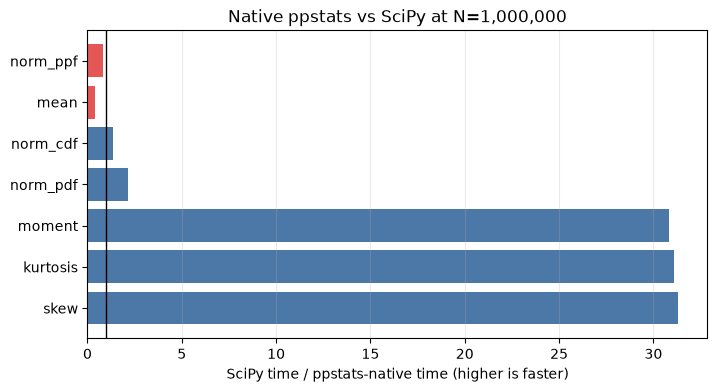

{'skew': np.float64(31.3),
 'kurtosis': np.float64(31.09),
 'moment': np.float64(30.81),
 'norm_pdf': np.float64(2.16),
 'norm_cdf': np.float64(1.34),
 'mean': np.float64(0.37),
 'norm_ppf': np.float64(0.84)}

In [16]:
summary_functions = ['skew', 'kurtosis', 'moment', 'norm_pdf', 'norm_cdf', 'mean', 'norm_ppf']
summary_n = 1_000_000
summary_speedups = []
for function in summary_functions:
    pp_time, scipy_time = performance_result(function, summary_n)
    summary_speedups.append(scipy_time / pp_time)

fig, axis = plt.subplots(figsize=(8, 4))
colors = ['#4c78a8' if value >= 1 else '#e45756' for value in summary_speedups]
axis.barh(summary_functions, summary_speedups, color=colors)
axis.axvline(1.0, color='black', lw=1)
axis.set_xlabel('SciPy time / ppstats-native time (higher is faster)')
axis.set_title(f'Native ppstats vs SciPy at N={summary_n:,}')
axis.grid(axis='x', alpha=0.25)
display(fig); plt.close(fig)
dict(zip(summary_functions, np.round(summary_speedups, 2)))

## What this exercises

The demo exercised reduction gufuncs, scalar broadcast ufuncs, the compiled CPython extension, and the cross-package POST dependency on ppspecial (`ndtr`/`ndtri`, plus logistic `expit`/`logit`). ppstats deliberately does not yet provide SciPy-style distribution classes, `rvs`, or `fit`; those need compiler support for structs, RNG, and callable parameters. See the [PostSciPy roadmap](https://github.com/openteams-ai/postpython/blob/main/postscipy-roadmap.md) for the broader package-by-package plan.